In [1]:
!python --version

Python 3.12.13


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("/content/Group 2 Job 1_2_3 _ Breast Cancer Dataset.csv")
df.head(5)

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [4]:
df.shape

(569, 32)

In [5]:
df.columns

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

In [7]:
df.describe()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
x.radius_mean,0
x.texture_mean,0
x.perimeter_mean,0
x.area_mean,0
x.smoothness_mean,0
x.compactness_mean,0
x.concavity_mean,0
x.concave_pts_mean,0
x.symmetry_mean,0


In [9]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [10]:
df

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.147400,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873,M
565,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.138900,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.41070,0.22160,0.2060,0.07115,M
566,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637,M
567,16.600,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.053020,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.34030,0.14180,0.2218,0.07820,M


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactness_se     569 non-null    flo

In [12]:
df.shape

(569, 31)

In [13]:
df['y'] = df['y'].map({'M':1, 'B':0})

In [14]:
df

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,0
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,0
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,0
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,0
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.147400,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873,1
565,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.138900,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.41070,0.22160,0.2060,0.07115,1
566,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637,1
567,16.600,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.053020,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.34030,0.14180,0.2218,0.07820,1


In [15]:
df['y']

,y
0,0
1,0
2,0
3,0
4,0
...,...
564,1
565,1
566,1
567,1


In [20]:
df.duplicated().sum()

np.int64(0)

<Axes: >

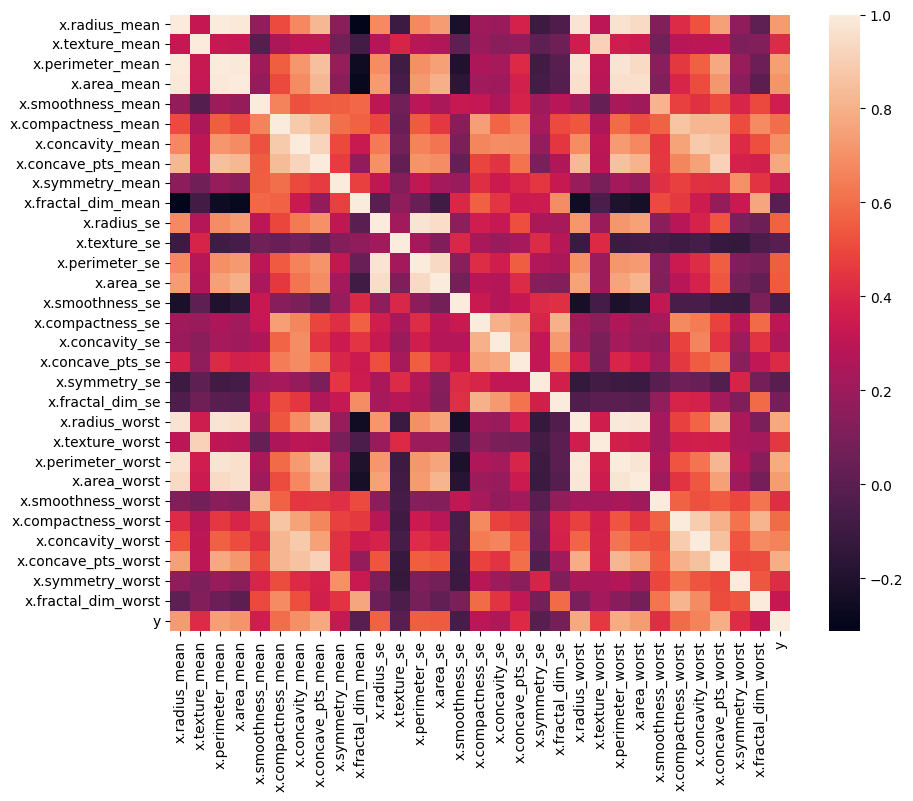

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)

In [22]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [29]:
X

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,15.110,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,10.230,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,13.300,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,8.964,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.147400,0.2149,0.06879,...,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873
565,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.138900,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.41070,0.22160,0.2060,0.07115
566,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637
567,16.600,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.053020,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.34030,0.14180,0.2218,0.07820


In [30]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
564,1
565,1
566,1
567,1


In [23]:
X.shape

(569, 30)

In [24]:
y.shape

(569,)

In [25]:
X_train.shape

(455, 30)

In [26]:
X_test.shape

(114, 30)

In [27]:
y_train.shape

(455,)

In [28]:
y_test.shape

(114,)

In [31]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
model

LogisticRegression()

In [33]:
y_pred

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0])

In [34]:
y_pred.shape

(114,)

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
scaler

StandardScaler()

In [37]:
X_train_scaled

array([[ 0.11220009, -0.99307021,  0.12326792, ...,  0.3461765 ,
         0.35618797,  0.02390351],
       [-0.23322311, -0.59010674, -0.29220858, ..., -0.6971757 ,
        -0.27585078, -0.4480491 ],
       [ 1.63039079,  1.03824273,  1.69513383, ...,  1.1320898 ,
         0.57663075,  0.55147343],
       ...,
       [-0.53407558, -1.664676  , -0.55990626, ..., -0.33798643,
        -0.1432768 , -0.87762661],
       [ 0.10662875,  1.07594691,  0.07481585, ..., -0.70330164,
        -0.61345197, -0.62602449],
       [-0.72350121, -0.26490815, -0.70849261, ...,  0.07872692,
        -0.17564952,  0.35442924]])

In [38]:
X_train_scaled.shape

(455, 30)

In [39]:
X_test_scaled

array([[-0.26943683, -1.10618277, -0.32208735, ..., -0.24549967,
        -1.37652314, -1.17690072],
       [ 0.1400568 ,  1.40585852,  0.08006483, ..., -0.10505129,
        -0.30514038, -0.77963421],
       [ 0.53005074, -1.08261765,  0.46768139, ..., -0.05425081,
        -0.21881314, -0.74997164],
       ...,
       [-0.49229051, -0.20128234, -0.4694624 , ..., -0.22458183,
         0.14499453,  0.17062727],
       [-1.53524574, -0.85403603, -1.48897471, ..., -0.17228722,
         0.00933744,  0.92278519],
       [-0.14686731, -0.18243025, -0.16098422, ...,  0.17733961,
        -0.10936252,  0.31946979]])

In [40]:
X_test_scaled.shape

(114, 30)

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.svm import SVC

In [45]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_y_pred = dt_model.predict(X_test_scaled)

In [46]:
dt_model

DecisionTreeClassifier(random_state=42)

In [47]:
dt_y_pred

array([0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0])

In [48]:
dt_y_pred.shape

(114,)

In [49]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_y_pred = rf_model.predict(X_test_scaled)

In [50]:
rf_model

RandomForestClassifier(random_state=42)

In [51]:
rf_y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0])

In [52]:
rf_y_pred.shape

(114,)

In [65]:
svc_model = SVC(random_state=42, probability=True) # probability=True is needed for ROC curve
svc_model.fit(X_train_scaled, y_train)
svc_y_pred = svc_model.predict(X_test_scaled)

In [66]:
svc_model

SVC(probability=True, random_state=42)

In [67]:
svc_y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0])

In [68]:
svc_y_pred.shape

(114,)

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        79
           1       0.89      0.94      0.92        35

    accuracy                           0.95       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [56]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_y_pred))
print(classification_report(y_test, dt_y_pred))

Decision Tree Accuracy: 0.9385964912280702
              precision    recall  f1-score   support

           0       0.95      0.96      0.96        79
           1       0.91      0.89      0.90        35

    accuracy                           0.94       114
   macro avg       0.93      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [57]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))
print(classification_report(y_test, rf_y_pred))

Random Forest Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.97      0.97      0.97        35

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [69]:
print("SVC Accuracy:", accuracy_score(y_test, svc_y_pred))
print(classification_report(y_test, svc_y_pred))

SVC Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        79
           1       1.00      0.94      0.97        35

    accuracy                           0.98       114
   macro avg       0.99      0.97      0.98       114
weighted avg       0.98      0.98      0.98       114



<Axes: >

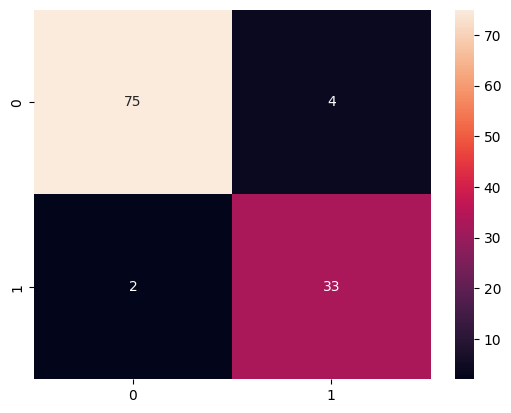

In [58]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

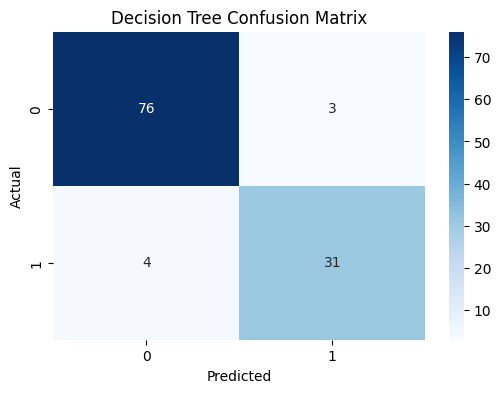

In [59]:
dt_cm = confusion_matrix(y_test, dt_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

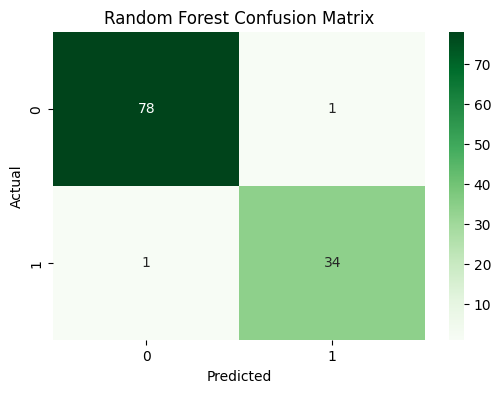

In [60]:
rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

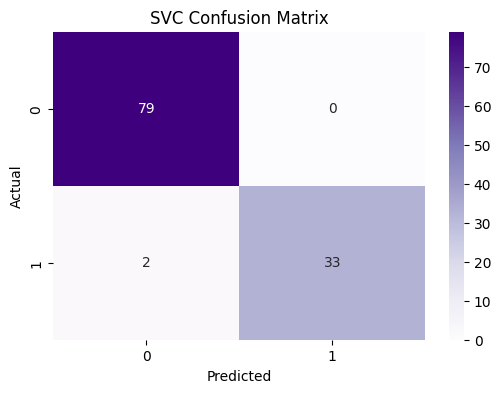

In [70]:
svc_cm = confusion_matrix(y_test, svc_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(svc_cm, annot=True, fmt='d', cmap='Purples')
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

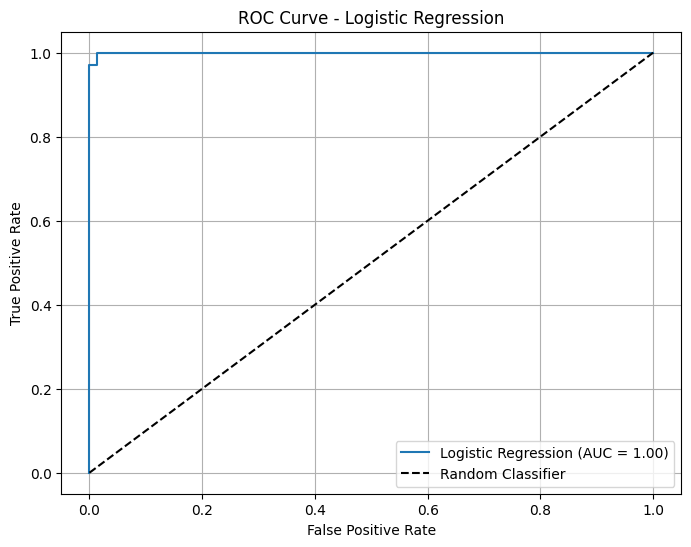

In [78]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

In [75]:
auc_lr

np.float64(0.9996383363471971)

In [74]:
model_lr.predict_proba(X_test_scaled)

array([[9.83558284e-01, 1.64417165e-02],
       [6.09586464e-01, 3.90413536e-01],
       [8.91989144e-01, 1.08010856e-01],
       [9.94058650e-01, 5.94135031e-03],
       [2.13896164e-06, 9.99997861e-01],
       [1.14307640e-04, 9.99885692e-01],
       [3.65753829e-08, 9.99999963e-01],
       [9.98031766e-01, 1.96823439e-03],
       [9.99672260e-01, 3.27740237e-04],
       [2.13045773e-04, 9.99786954e-01],
       [9.99898955e-01, 1.01045113e-04],
       [9.99716430e-01, 2.83570468e-04],
       [9.99952964e-01, 4.70358441e-05],
       [9.99779100e-01, 2.20899937e-04],
       [9.74761882e-01, 2.52381176e-02],
       [9.98488925e-01, 1.51107508e-03],
       [9.68011921e-01, 3.19880792e-02],
       [9.97587883e-01, 2.41211724e-03],
       [9.99980368e-01, 1.96319745e-05],
       [9.99990503e-01, 9.49720036e-06],
       [5.29972900e-03, 9.94700271e-01],
       [1.27100108e-10, 1.00000000e+00],
       [2.59667347e-03, 9.97403327e-01],
       [9.99292446e-01, 7.07553840e-04],
       [9.384452

In [73]:
y_pred_proba_lr

array([1.64417165e-02, 3.90413536e-01, 1.08010856e-01, 5.94135031e-03,
       9.99997861e-01, 9.99885692e-01, 9.99999963e-01, 1.96823439e-03,
       3.27740237e-04, 9.99786954e-01, 1.01045113e-04, 2.83570468e-04,
       4.70358441e-05, 2.20899937e-04, 2.52381176e-02, 1.51107508e-03,
       3.19880792e-02, 2.41211724e-03, 1.96319745e-05, 9.49720036e-06,
       9.94700271e-01, 1.00000000e+00, 9.97403327e-01, 7.07553840e-04,
       6.15547813e-02, 2.24335015e-03, 8.08854547e-01, 2.86816623e-03,
       1.16983866e-02, 2.19250831e-01, 9.99999912e-01, 7.05012773e-03,
       8.15253042e-03, 7.06532888e-05, 9.16623334e-02, 2.91508796e-02,
       9.66721045e-01, 2.90595361e-06, 1.33958284e-04, 9.99904580e-01,
       9.99747421e-01, 1.04212802e-01, 1.05793058e-05, 9.99933160e-01,
       3.51308642e-05, 9.99997807e-01, 1.51182376e-04, 9.97612447e-01,
       1.44512220e-06, 1.01781619e-01, 2.05831502e-03, 2.76205124e-02,
       9.99931755e-01, 6.59509515e-05, 9.99998103e-01, 2.90865062e-05,
      

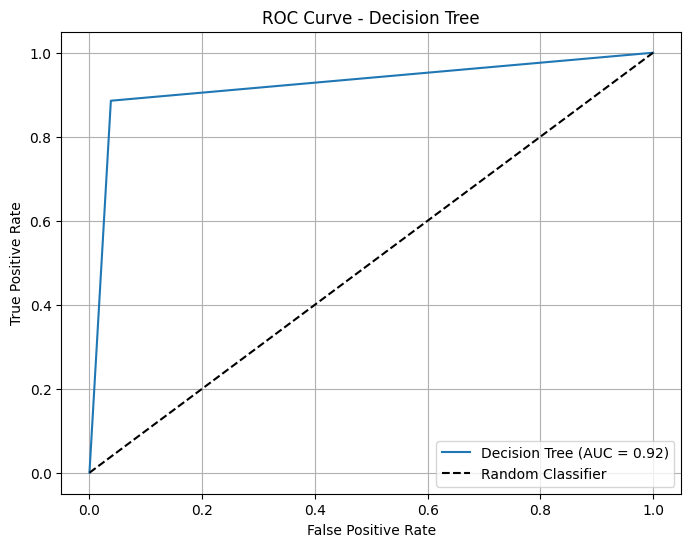

In [79]:
plt.figure(figsize=(8, 6))
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

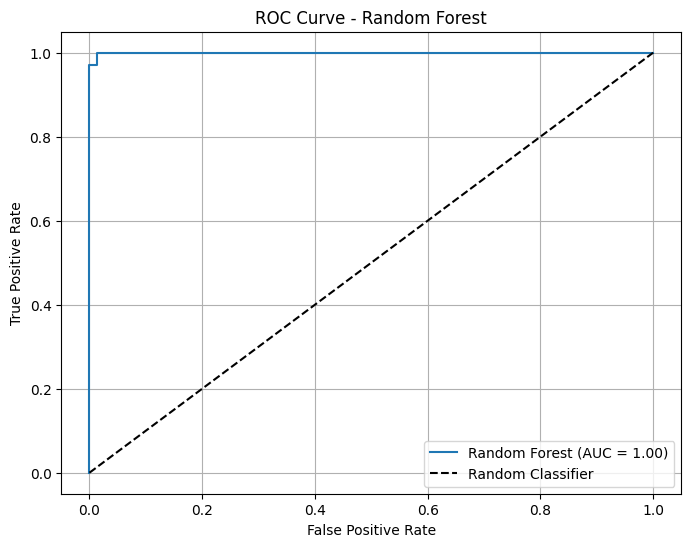

In [80]:
plt.figure(figsize=(8, 6))
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

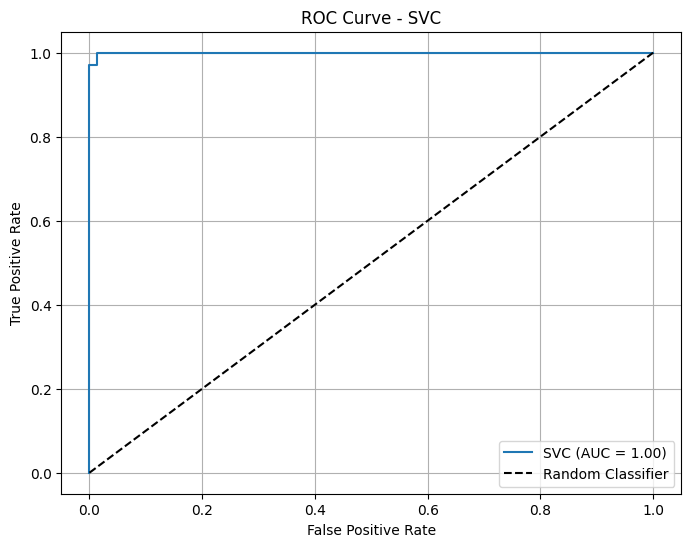

In [81]:
plt.figure(figsize=(8, 6))
y_pred_proba_svc = svc_model.predict_proba(X_test_scaled)[:, 1]
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_proba_svc)
auc_svc = roc_auc_score(y_test, y_pred_proba_svc)
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {auc_svc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVC')
plt.legend()
plt.grid(True)
plt.show()

In [85]:
print('--- Logistic Regression Performance ---')
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
y_train_pred_lr = model_lr.predict(X_train_scaled)
print(f'Training Accuracy (LR): {accuracy_score(y_train, y_train_pred_lr):.4f}')
print(f'Testing Accuracy (LR): {accuracy_score(y_test, model_lr.predict(X_test_scaled)):.4f}')

print('\n--- Decision Tree Performance ---')
print(f'Training Accuracy (DT): {accuracy_score(y_train, dt_model.predict(X_train_scaled)):.4f}')
print(f'Testing Accuracy (DT): {accuracy_score(y_test, dt_y_pred):.4f}')

print('\n--- Random Forest Performance ---')
print(f'Training Accuracy (RF): {accuracy_score(y_train, rf_model.predict(X_train_scaled)):.4f}')
print(f'Testing Accuracy (RF): {accuracy_score(y_test, rf_y_pred):.4f}')

print('\n--- SVC Performance ---')
print(f'Training Accuracy (SVC): {accuracy_score(y_train, svc_model.predict(X_train_scaled)):.4f}')
print(f'Testing Accuracy (SVC): {accuracy_score(y_test, svc_y_pred):.4f}')

--- Logistic Regression Performance ---
Training Accuracy (LR): 0.9846
Testing Accuracy (LR): 0.9912

--- Decision Tree Performance ---
Training Accuracy (DT): 1.0000
Testing Accuracy (DT): 0.9386

--- Random Forest Performance ---
Training Accuracy (RF): 1.0000
Testing Accuracy (RF): 0.9825

--- SVC Performance ---
Training Accuracy (SVC): 0.9868
Testing Accuracy (SVC): 0.9825


Based on the above output:

*   **Logistic Regression:**
    *   Training Accuracy: 0.9846
    *   Testing Accuracy: 0.9912
    *   *Interpretation:* The training and testing accuracies are very close and high, indicating a well-generalized model with no significant overfitting or underfitting.

*   **Decision Tree:**
    *   Training Accuracy: 1.0000
    *   Testing Accuracy: 0.9386
    *   *Interpretation:* The perfect training accuracy (1.0000) combined with a lower testing accuracy (0.9386) suggests that the Decision Tree model is **overfitting** the training data. It has learned the training data too well, including noise, and doesn't generalize as effectively to unseen data.

*   **Random Forest:**
    *   Training Accuracy: 1.0000
    *   Testing Accuracy: 0.9825
    *   *Interpretation:* Similar to the Decision Tree, Random Forest also shows a perfect training accuracy. However, its testing accuracy (0.9825) is much closer to the training accuracy than the Decision Tree, indicating much less overfitting. The ensemble nature of Random Forest helps in reducing overfitting compared to a single Decision Tree.

*   **SVC:**
    *   Training Accuracy: 0.9868
    *   Testing Accuracy: 0.9825
    *   *Interpretation:* The training and testing accuracies are very close and high. This indicates a well-generalized model without significant overfitting or underfitting, similar to Logistic Regression.

In [87]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth' : [4, 6, 8], # Maximum depth of the tree
    'criterion' :['gini', 'entropy'] # Function to measure the quality of a split
}

# Create a GridSearchCV object
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV object to the training data
grid_search_rf.fit(X_train_scaled, y_train)

# Print the best parameters and the best score
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best Score: {grid_search_rf.best_score_:.4f}")

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_


Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Best Parameters: {'criterion': 'entropy', 'max_depth': 6, 'max_features': 'log2', 'n_estimators': 100}
Best Score: 0.9648


Tuned Random Forest Accuracy: 0.9912280701754386
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        79
           1       1.00      0.97      0.99        35

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



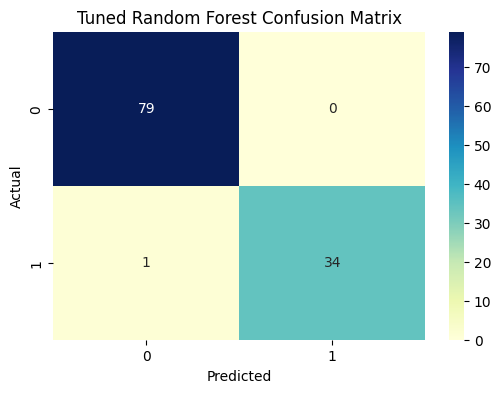

In [88]:
tuned_rf_y_pred = best_rf_model.predict(X_test_scaled)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, tuned_rf_y_pred))
print(classification_report(y_test, tuned_rf_y_pred))

tuned_rf_cm = confusion_matrix(y_test, tuned_rf_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(tuned_rf_cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [89]:
import joblib

# Save the best performing Random Forest model
model_filename = 'best_random_forest_model.pkl'
joblib.dump(best_rf_model, model_filename)

print(f"Model successfully saved as '{model_filename}'")

Model successfully saved as 'best_random_forest_model.pkl'
